In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df_clean = pd.read_parquet("perm_visas_clean.parquet")

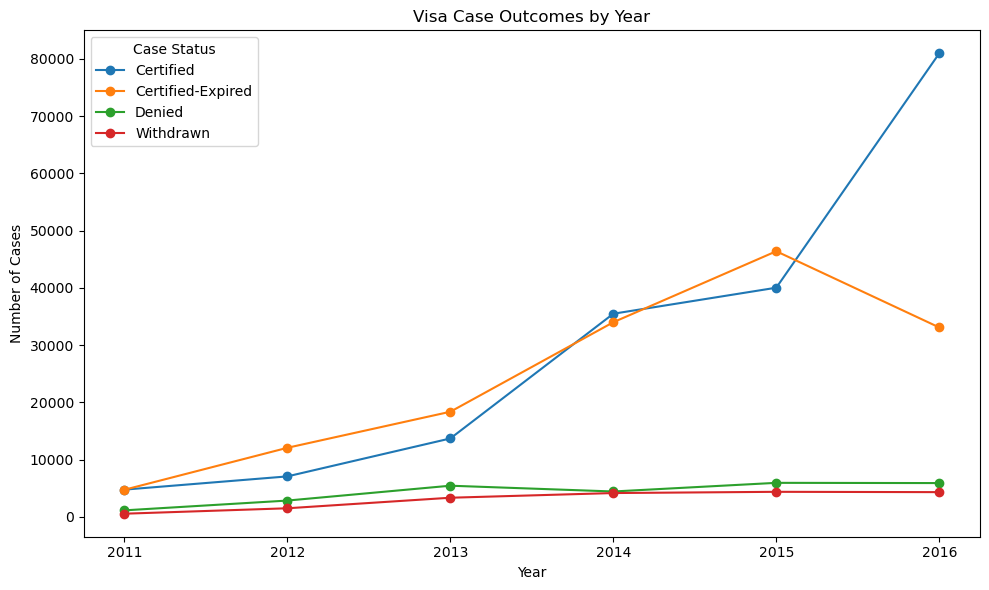

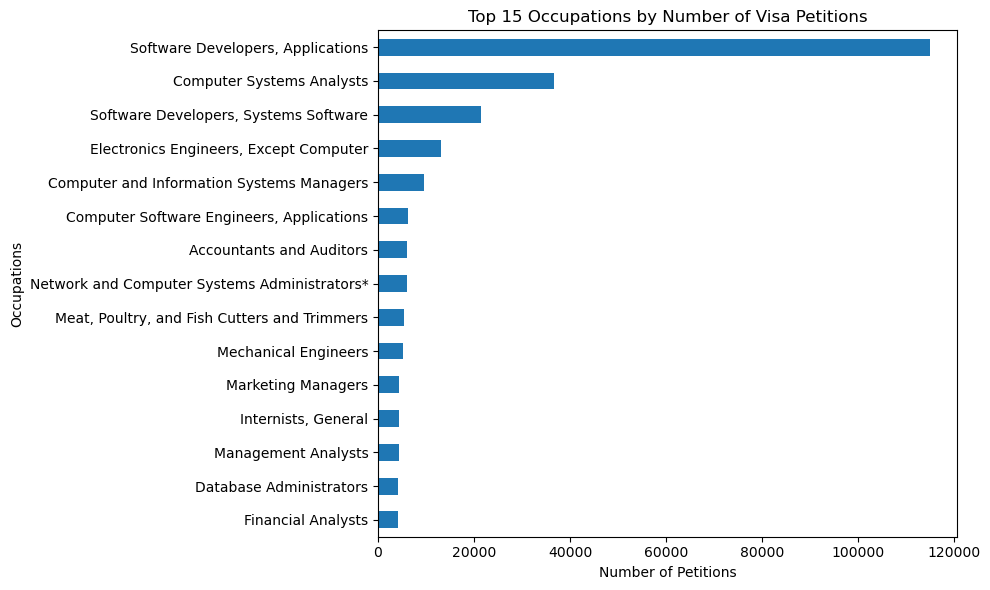

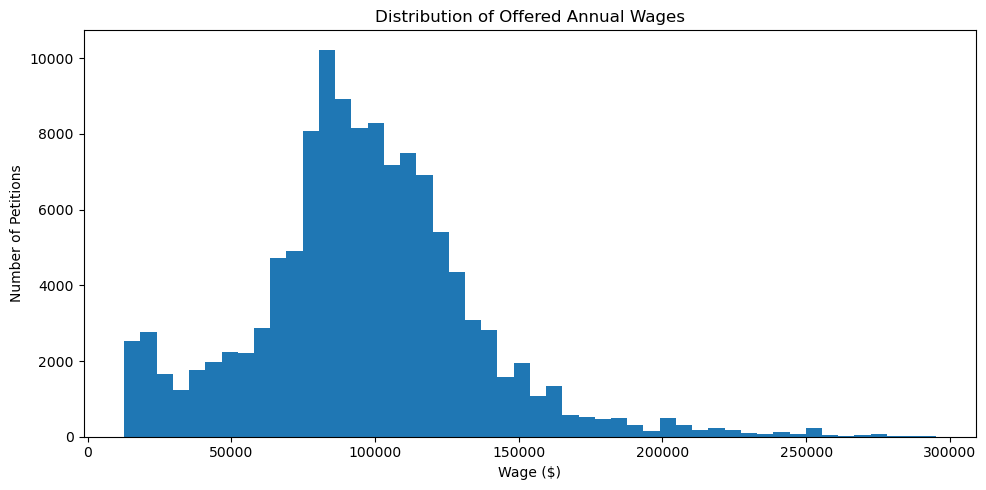

In [4]:
# outcomes over time — keeps ALL case statuses on purpose
status_by_year = df_clean.groupby(['decision_year', 'case_status']).size().unstack(fill_value=0)
status_by_year.plot(kind='line', figsize=(10, 6), marker='o')
plt.title("Visa Case Outcomes by Year")
plt.xlabel("Year"); plt.ylabel("Number of Cases")
plt.legend(title="Case Status")
plt.tight_layout(); plt.show()

# top occupations
top_occupations = df_clean['pw_soc_title'].value_counts().head(15)
plt.figure(figsize=(10, 6))
top_occupations.sort_values().plot(kind='barh')
plt.title("Top 15 Occupations by Number of Visa Petitions")
plt.xlabel("Number of Petitions")
plt.ylabel("Occupations")
plt.tight_layout(); plt.show()

# wage distribution
yearly_wage_df = df_clean[df_clean['wage_offer_unit_of_pay_9089'] == 'Year'].copy()
wages = yearly_wage_df['wage_offer_from_9089']
wages = wages[(wages > 10000) & (wages < 300000)]
plt.figure(figsize=(10, 5))
plt.hist(wages, bins=50)
plt.title("Distribution of Offered Annual Wages")
plt.xlabel("Wage ($)"); plt.ylabel("Number of Petitions")
plt.tight_layout(); plt.show()